# Carga y exploración inicial de datos

In [1]:
import pandas as pd 
import numpy as np      ##importamos librerias
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('01_DiatomInventories_GTstudentproject_B.csv')
valores_nulos=df.isnull().sum() ##leemos el dataset
valores_nulos

TaxonName                           0
TaxonCode                           0
SamplingOperations_code             0
CodeSite_SamplingOperations         0
Date_SamplingOperation              0
Abundance_nbcell                    0
TotalAbundance_SamplingOperation    0
Abundance_pm                        0
dtype: int64

In [3]:
###separación de variables cuantitativas y 
#cualitativas para facilitar el análisis siguiente 
#(gráficas, estadísticas y categorizaciones)
cuantitativas= df.select_dtypes(include=["number"]) 
cualitativas = df.select_dtypes(include=["object", "category"])

<Figure size 1500x800 with 0 Axes>

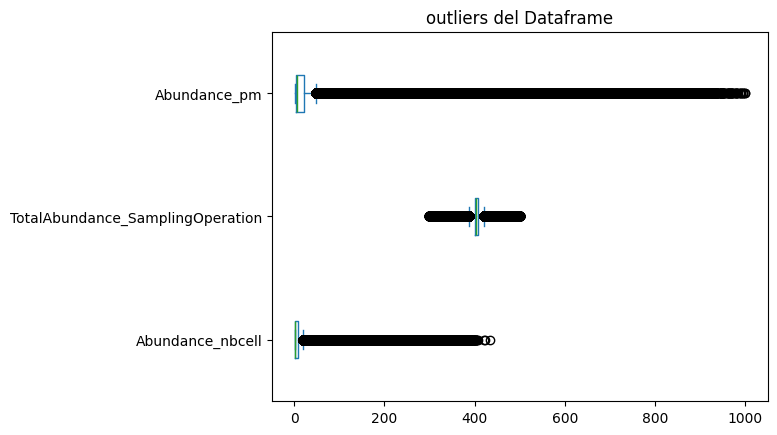

In [4]:
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)  ##permite identificar de forma visual la presencia de valores atípicos en el dataset
plt.title("outliers del Dataframe")
plt.show()

In [5]:
y=cuantitativas       ###cálculo de límites para detectar outliers
Limite_Superior= y.mean() + 3*y.std()
Limite_Inferior= y.mean() - 3*y.std()
print("Limite superior permitido", Limite_Superior)
print("Limite inferior permitido", Limite_Inferior)

Limite superior permitido Abundance_nbcell                     94.948382
TotalAbundance_SamplingOperation    437.096025
Abundance_pm                        233.878730
dtype: float64
Limite inferior permitido Abundance_nbcell                    -71.124054
TotalAbundance_SamplingOperation    374.808697
Abundance_pm                       -175.176372
dtype: float64


In [6]:
data3= cuantitativas[(y<=Limite_Superior)&(y>=Limite_Inferior)]
data3  ##filtrado de datos dentro de los límites

,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,8.0,420.0,19.047619
1,1.0,404.0,2.475248
2,1.0,400.0,2.500000
3,2.0,400.0,5.000000
4,1.0,400.0,2.500000
...,...,...,...
1643867,1.0,412.0,2.427184
1643868,1.0,400.0,2.500000
1643869,1.0,403.0,2.481390
1643870,7.0,400.0,17.500000


In [7]:
valores_nulos=data3.isnull().sum()
valores_nulos  ##contamos cuántos nulos quedan en cada columna

Abundance_nbcell                    37619
TotalAbundance_SamplingOperation    34628
Abundance_pm                        37352
dtype: int64

In [8]:
data_clean=data3.copy()
data_clean=data_clean.fillna(round(data3.mean(),1))
data_clean   
##lleno los espacios vacíos usando la media 
##de cada columna (para no perder datos y mantener el promedio estable)

,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,8.0,420.0,19.047619
1,1.0,404.0,2.475248
2,1.0,400.0,2.500000
3,2.0,400.0,5.000000
4,1.0,400.0,2.500000
...,...,...,...
1643867,1.0,412.0,2.427184
1643868,1.0,400.0,2.500000
1643869,1.0,403.0,2.481390
1643870,7.0,400.0,17.500000


In [9]:
valores_nulos=data_clean.isnull().sum() ##reviso si todavía hay valores vacíos
valores_nulos

Abundance_nbcell                    0
TotalAbundance_SamplingOperation    0
Abundance_pm                        0
dtype: int64

In [10]:
Datos_limpios = pd.concat([cualitativas, data_clean], axis=1)
Datos_limpios ##dataset final limpio

,TaxonName,TaxonCode,SamplingOperations_code,CodeSite_SamplingOperations,Date_SamplingOperation,Abundance_nbcell,TotalAbundance_SamplingOperation,Abundance_pm
0,Achnanthes aapajaervensis,Achaa01,S04094200_20120910,S04094200,2012-09-10,8.0,420.0,19.047619
1,Achnanthes aapajaervensis,Achaa01,S05155300_20100728,S05155300,2010-07-28,1.0,404.0,2.475248
2,Achnanthes affinis,Achaf01,S02018780_20070808,S02018780,2007-08-08,1.0,400.0,2.500000
3,Achnanthes affinis,Achaf01,S02022675_20090803,S02022675,2009-08-03,2.0,400.0,5.000000
4,Achnanthes affinis,Achaf01,S02094920_20120726,S02094920,2012-07-26,1.0,400.0,2.500000
...,...,...,...,...,...,...,...,...
1643867,Zygoceros surirella,Zygsu01,S03231260_20130806,S03231260,2013-08-06,1.0,412.0,2.427184
1643868,Zygoceros surirella,Zygsu01,S03269295_20110804,S03269295,2011-08-04,1.0,400.0,2.500000
1643869,Zygoceros surirella,Zygsu01,S05076010_20120606,S05076010,2012-06-06,1.0,403.0,2.481390
1643870,Zygoceros surirella,Zygsu01,S05076010_20220831,S05076010,2022-08-31,7.0,400.0,17.500000


## Preprocesamiento de valores nulos

In [11]:
#reemplazo de nulos
cat_cols = df.select_dtypes(include=['object', 'category']).columns #columnas de texto/categoría
num_cols = df.select_dtypes(include=['number']).columns #columnas númericas
df_clean = df.copy()   #hago una copia del dataframe original
#para columnas de texto: relleno los vacíos con "sin_dato"
df_clean[cat_cols] = df_clean[cat_cols].fillna("sin_dato")
#para columnas numéricas relleno los vacíos con la mediana  
for col in num_cols:
    med = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(med)
##imprimo
print("nulos restantes:")
df_clean.isnull().sum().sort_values(ascending=False).head()


nulos restantes:


TaxonName                      0
TaxonCode                      0
SamplingOperations_code        0
CodeSite_SamplingOperations    0
Date_SamplingOperation         0
dtype: int64

## Análisis univariado de variables categóricas

TaxonName


TaxonName
Achnanthes minutissima      43691
Amphora pediculus           39209
Cocconeis euglypta          38570
Sellaphora nigri            38039
Navicula cryptotenella      37723
Nitzschia dissipata         34461
Vibrio tripunctatus         30899
Rhoicosphenia abbreviata    30560
Navicula permitis           29789
Achnanthes lanceolata       27239
Name: count, dtype: int64

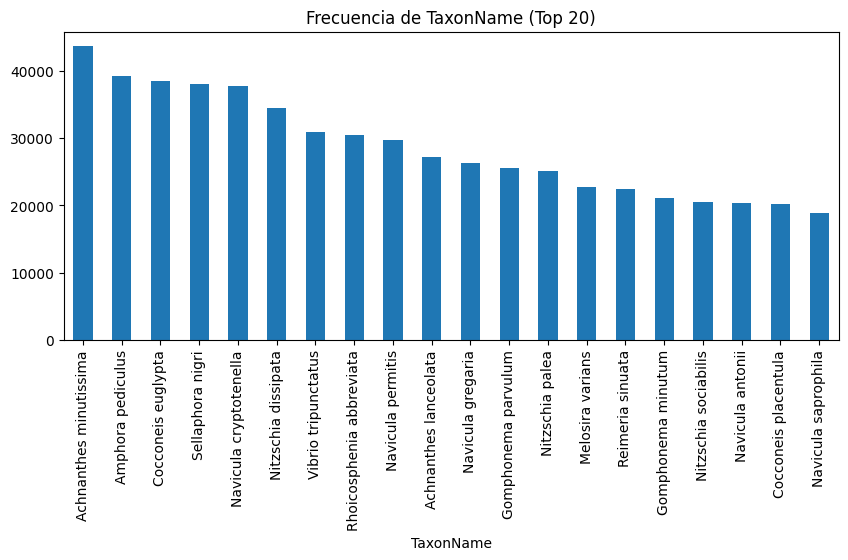

TaxonCode


TaxonCode
Achmi02    43691
Amppe02    39209
Coceu01    38570
Selni01    38039
Navcr09    37723
Nitdi04    34461
Vibtr01    30899
Rhoab01    30560
Navpe05    29789
Achla02    27239
Name: count, dtype: int64

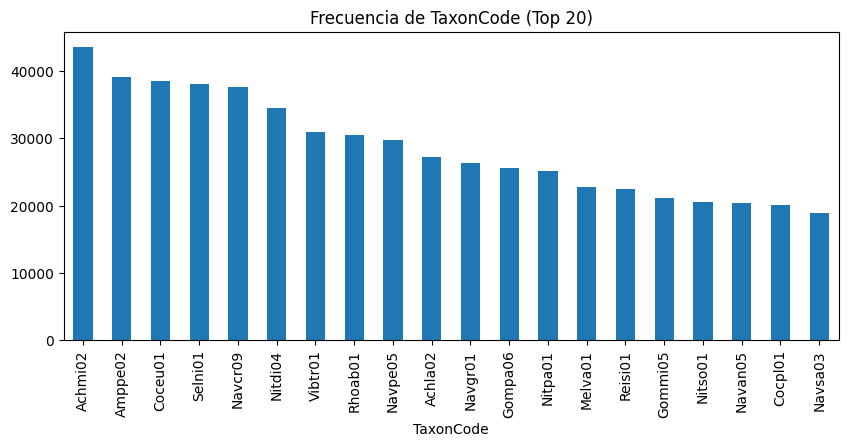

SamplingOperations_code


SamplingOperations_code
S05119000_20160627    97
S05051000_20080722    97
S05068700_20070904    94
S04215520_20200702    92
S04304002_20200907    92
S04103550_20150811    92
S04615008_20130719    91
S03132260_20120718    91
S04103935_20200929    89
S04473008_20160711    89
Name: count, dtype: int64

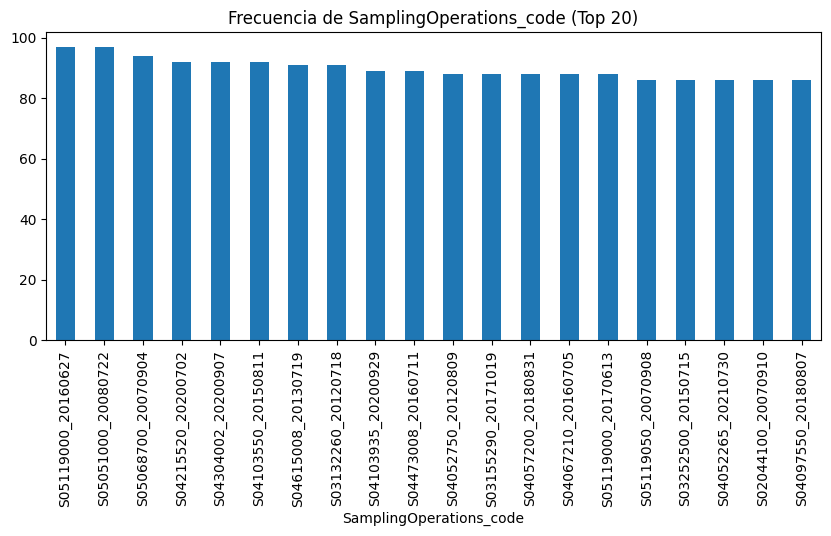

Date_SamplingOperation


Date_SamplingOperation
2013-07-11    4545
2013-07-17    4431
2013-07-16    4401
2015-07-08    4376
2018-07-17    4278
2015-06-24    4126
2012-07-25    4091
2012-07-24    3833
2016-07-21    3742
2016-07-20    3706
Name: count, dtype: int64

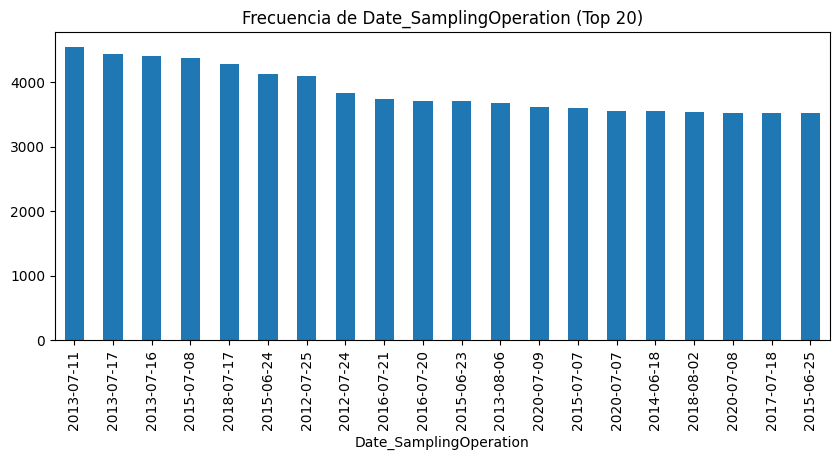

In [12]:
##análisis univariado de variables categóricas
##reviso cada columna de tipo categórica y muestro
##las 10 categorías más comunes en una tabla
##una gráfica de barras con las 20 categorías más frecuentes para ver su distribución

categoricas = ["TaxonName", "TaxonCode", "SamplingOperations_code", "Date_SamplingOperation"]

for col in categoricas:
    if col in df_clean.columns:
        print(f"{col}")
        display(df_clean[col].value_counts().head(10))
        df_clean[col].value_counts().head(20).plot(kind='bar', figsize=(10,4))
        plt.title(f"Frecuencia de {col} (Top 20)")
        plt.show()


## Categorización de variables numéricas (Regla de Sturges)

Abundance_nbcell -> k=22


Abundance_nbcell
(0.568, 20.636]       1428246
(20.636, 40.273]       104073
(40.273, 59.909]        39987
(59.909, 79.545]        22786
(79.545, 99.182]        14163
(99.182, 118.818]        8982
(118.818, 138.455]       6650
(138.455, 158.091]       4822
(158.091, 177.727]       3419
(177.727, 197.364]       2811
(197.364, 217.0]         2185
(217.0, 236.636]         1548
(236.636, 256.273]       1252
(256.273, 275.909]        876
(275.909, 295.545]        711
(295.545, 315.182]        513
(315.182, 334.818]        347
(334.818, 354.455]        250
(354.455, 374.091]        159
(374.091, 393.727]         68
(393.727, 413.364]         21
(413.364, 433.0]            3
Name: count, dtype: int64

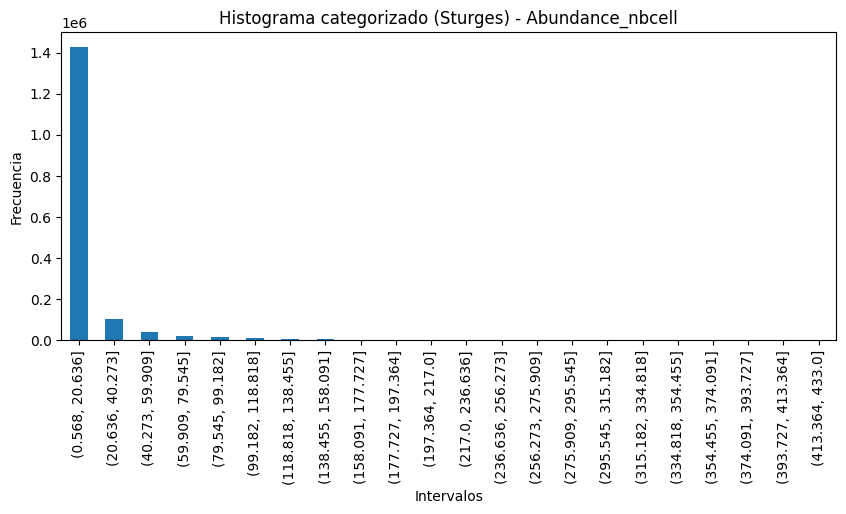

TotalAbundance_SamplingOperation -> k=22


TotalAbundance_SamplingOperation
(299.8, 309.091]         254
(309.091, 318.182]       424
(318.182, 327.273]       270
(327.273, 336.364]       347
(336.364, 345.455]       630
(345.455, 354.545]      1088
(354.545, 363.636]       926
(363.636, 372.727]       870
(372.727, 381.818]      2633
(381.818, 390.909]      6858
(390.909, 400.0]      431289
(400.0, 409.091]      838692
(409.091, 418.182]    241432
(418.182, 427.273]     66207
(427.273, 436.364]     21124
(436.364, 445.455]     10918
(445.455, 454.545]      6839
(454.545, 463.636]      4443
(463.636, 472.727]      3269
(472.727, 481.818]      2582
(481.818, 490.909]      1740
(490.909, 500.0]        1037
Name: count, dtype: int64

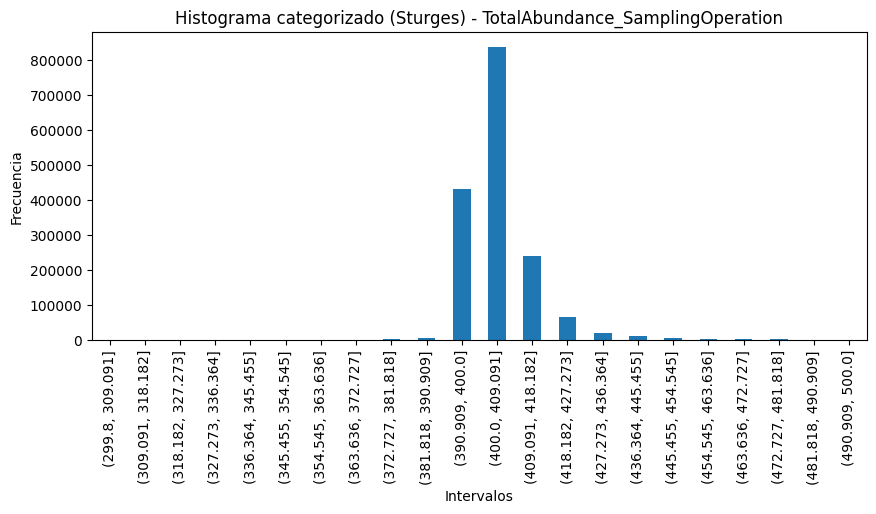

Abundance_pm -> k=22


Abundance_pm
(1.002, 47.364]       1414936
(47.364, 92.727]       108524
(92.727, 138.091]       43393
(138.091, 183.455]      23573
(183.455, 228.818]      14754
(228.818, 274.182]      10010
(274.182, 319.545]       7018
(319.545, 364.909]       5157
(364.909, 410.273]       3923
(410.273, 455.636]       2978
(455.636, 501.0]         2339
(501.0, 546.364]         1934
(546.364, 591.727]       1397
(591.727, 637.091]       1100
(637.091, 682.455]        837
(682.455, 727.818]        634
(727.818, 773.182]        466
(773.182, 818.545]        358
(818.545, 863.909]        254
(863.909, 909.273]        159
(909.273, 954.636]         92
(954.636, 1000.0]          36
Name: count, dtype: int64

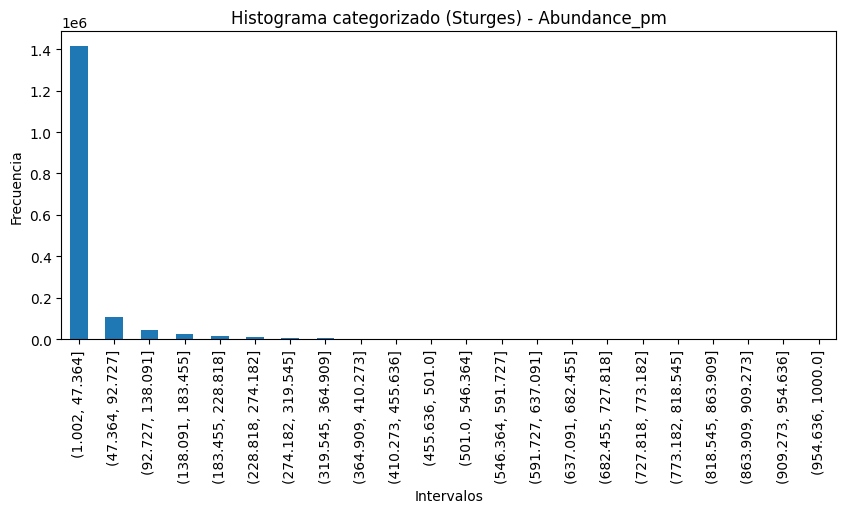

In [13]:
##categorización de variables numéricas con la regla de Sturges
#aquí calculo en cuántos grupos dividir cada columna numérica usando la fórmula de Sturges
#así puedo ver
#-cuántos datos hay en cada grupo en forma de tabla
#-un histograma que me deja ver cómo se distribuyen los datos
numericas_sturges = ["Abundance_nbcell", "TotalAbundance_SamplingOperation", "Abundance_pm"]

def sturges_bins(n):
    return int(np.ceil(1 + np.log2(n))) if n > 1 else 1

for col in numericas_sturges:
    if col in df_clean.columns:
        k = sturges_bins(len(df_clean[col].dropna()))
        print(f"{col} -> k={k}")
        cats = pd.cut(df_clean[col], bins=k)
        freq = cats.value_counts().sort_index()
        display(freq)
        freq.plot(kind='bar', figsize=(10,4))
        plt.title(f"Histograma categorizado (Sturges) - {col}")
        plt.xlabel("Intervalos")
        plt.ylabel("Frecuencia")
        plt.show()
